# Generalized Random Forest Module: Use Cases and Examples

Causal Forests and [Generalized Random Forests](https://arxiv.org/pdf/1610.01271.pdf) are a flexible method for estimating treatment effect heterogeneity with Random Forests. The `econml.grf` module implements a high-performance Cython version of the [`grf`](https://github.com/grf-labs/grf) R-package, with support for CausalForests, IVForests and RegressionForests. The module provides estimators that adhere to the scikit-learn fit and predict API, as well as providing methods for uncertainty quantification and confidence intervals.

Within the EconML SDK we use these estimators as final models for CATE estimation, such as in the case of `econml.dml.CausalForestDML`, where we combine a Causal Forest with Double Machine Learning, to residualize the treatment and outcome and call the `econml.grf.CausalForest` on the residuals. Similarly, the `econml.dr.ForestDRLearner` uses an `econml.grf.RegressionForest` as a final stage estimator on the doubly robust targets estimated by the first stage. The estimators here should primarily be used in conjunction with CateEstimators and not as standalone, but we provide here examples of their direct usage functionality.

The EconML SDK implements the following Generalized Random Forest variants:

* `CausalForest`: suitable for many continuous or discrete treatments, when there is no unobserved confounding

* `CausalIVForest`: suitable for many continuous or discrete treatments, when there is unobserved confounding and access to an instrument

* `RegressionForest`: an analogue of `sklearn.ensemble.RandomForestRegressor`, but with support for confidence intervals.

If you also have multiple outcomes, then the class `econml.grf.MultiOutputGRF`, is a wrapper class that wraps any generalized random forest and enables support for multiple outcomes by fitting a separate forest for each target outcome.

Our estimators provide support for the heterogeneity criterion as outlined in [Generalized Random Forests](https://arxiv.org/pdf/1610.01271.pdf), using `criterion='het'`, as well as a mean squared error criterion that penalizes high-variance splits, using `criterion='mse'`.[Generalized Random Forests](https://arxiv.org/pdf/1610.01271.pdf).

Uncertainty quantification and confidence intervals is computed via the Bootstrap-of-Little-Bags approach outlined in [Generalized Random Forests](https://arxiv.org/pdf/1610.01271.pdf).

The tree data structure that is used to store each tree is compatible with `sklearn.tree._tree.Tree` and so scikit-learn functionalities on trees can be applied to our trained trees (e.g. tree plotting).


## Notebook Contents

1. [Causal Forest: Heterogeneous causal effects with no unobserved confounders](#1.-Causal-Forest:-Heterogeneous-causal-effects-with-no-unobserved-confounders)
2. [Causal IV Forest: Heterogeneous causal effects with unobserved confounders](#2.-Causal-IV-Forest:-Heterogeneous-causal-effects-with-unobserved-confounders)
3. [Regression Forest: Random Forest Regressor with confidence intervals](#3.-Regression-Forest:-Random-Forest-Regressor-with-confidence-intervals)
4. [Combining with Double Machine Learning](#4.-Combining-with-Double-Machine-Learning)
6. [Customer Linear Moment Forest](#5.-Custom-Linear-Moment-Forest)

In [1]:
!pip install econml

from econml.grf import CausalForest, CausalIVForest, RegressionForest
from econml.dml import CausalForestDML
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
from sklearn.model_selection import train_test_split


  Using cached econml-0.16.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (37 kB)
  Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached sparse-0.17.0-py2.py3-none-any.whl.metadata (5.3 kB)
  Using cached shap-0.48.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (25 kB)
  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached econml-0.16.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (5.4 MB)
Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
Using cached shap-0.48.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.0 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
Using cached sparse-0.17.0-py2.py3-none-any.whl (259 kB)


## 1. Causal Forest: Heterogeneous causal effects with no unobserved confounders

In [111]:
data = pd.read_csv("clean_data.csv")

data["select"] = data["select"].map({"control": 0, "selected": 1}).astype(int)
data = pd.get_dummies(data, columns=["city", "educ_lb"], drop_first = False)
data.columns = data.columns.str.replace('.', '_', regex=False)

train_data, val_data = train_test_split(
    data,
    test_size=0.3,        # 30% validation, 70% training
    random_state=0,      # ensures reproducibility
    shuffle=True
)

treatment_var = "select"      # modify if needed
outcome_var   = "salary_06"     # modify if needed

# -------------------------
# 2. Build feature list (X)
# -------------------------

feature_cols = [
    "age_lb", "salary_04", "empl_04", 'dwomen', 'dmarried_lb',
    "city_1_0", "city_2_0", "city_3_0", "city_4_0", "city_5_0", "city_6_0",
    "educ_lb_0_0","educ_lb_2_0","educ_lb_3_0","educ_lb_4_0","educ_lb_5_0",
    "educ_lb_6_0","educ_lb_7_0","educ_lb_8_0","educ_lb_9_0","educ_lb_10_0",
    "educ_lb_12_0","educ_lb_13_0","educ_lb_14_0","educ_lb_16_0"
]
# -------------------------
# 3. Convert to numpy arrays
# -------------------------
X_train = train_data[feature_cols].to_numpy()
T_train = train_data[[treatment_var]].to_numpy()
y_train = train_data[[outcome_var]].to_numpy()

X_val = val_data[feature_cols].to_numpy()
T_val = val_data[[treatment_var]].to_numpy()
y_val = val_data[[outcome_var]].to_numpy()

In [112]:
data.columns

Index(['age_s', 'dmarried_s', 'empl_06', 'salary_06', 'profit_06', 'days_06',
       'hours_06', 'contract_06', 'dformal_06', 'educ_s', 'age_lb',
       'dmarried_lb', 'empl_04', 'salary_04', 'profit_04', 'days_04',
       'hours_04', 'contract_04', 'dformal_04', 'select', 'pempl_06',
       'pempl_04', 'dcontinue', 'codigo_ecap', 'codigo_curs', 'dwomen',
       'p_selecap', 'city_1_0', 'city_2_0', 'city_3_0', 'city_4_0', 'city_5_0',
       'city_6_0', 'city_7_0', 'educ_lb_0_0', 'educ_lb_2_0', 'educ_lb_3_0',
       'educ_lb_4_0', 'educ_lb_5_0', 'educ_lb_6_0', 'educ_lb_7_0',
       'educ_lb_8_0', 'educ_lb_9_0', 'educ_lb_10_0', 'educ_lb_11_0',
       'educ_lb_12_0', 'educ_lb_13_0', 'educ_lb_14_0', 'educ_lb_16_0'],
      dtype='object')

In [113]:
est = CausalForest(criterion='het', n_estimators=400, min_samples_leaf=5, max_depth=None,
                   min_var_fraction_leaf=True, min_var_leaf_on_val=True,
                   min_impurity_decrease = 0.0, max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)

In [114]:
est.fit(X_train, T_train, y_train)

CausalForest(criterion='het', min_var_fraction_leaf=True,
             min_var_leaf_on_val=True, n_estimators=400, random_state=1235)

In [115]:
point, lb, ub = est.predict(X_val, interval=True, alpha=0.01)

In [116]:
point = est.predict(X_val)

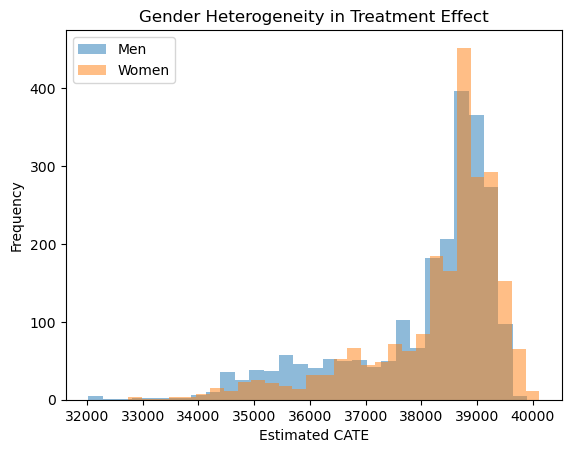

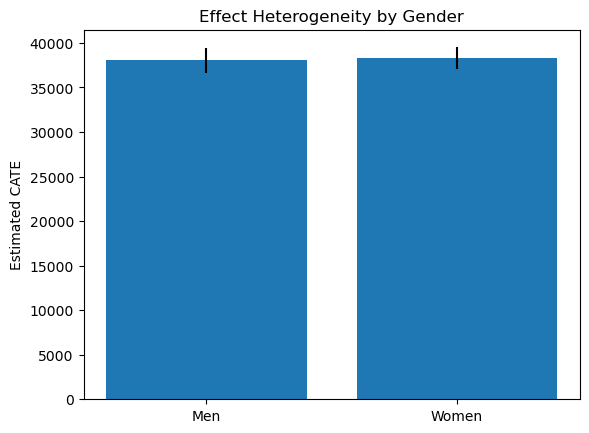

In [128]:
# 1. Identify gender dummy index
idx = feature_cols.index("dwomen")

# 2. Build test sets
X_base = X_train[:].copy()

X_test_men = X_base.copy()
X_test_men[:, idx] = 0

X_test_women = X_base.copy()
X_test_women[:, idx] = 1

# 3. Predict CATE + intervals

# MEN
point_men = est.predict(X_test_men)
lb_men, ub_men = est.predict_interval(X_test_men)

# WOMEN
point_women = est.predict(X_test_women)
lb_women, ub_women = est.predict_interval(X_test_women)


plt.hist(point_men, bins=30, alpha=0.5, label="Men")
plt.hist(point_women, bins=30, alpha=0.5, label="Women")
plt.legend()
plt.xlabel("Estimated CATE")
plt.ylabel("Frequency")
plt.title("Gender Heterogeneity in Treatment Effect")
plt.show()

plt.bar(["Men","Women"], [np.mean(point_men), np.mean(point_women)], yerr=[
    np.std(point_men), np.std(point_women)
])
plt.ylabel("Estimated CATE")
plt.title("Effect Heterogeneity by Gender")
plt.show()

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

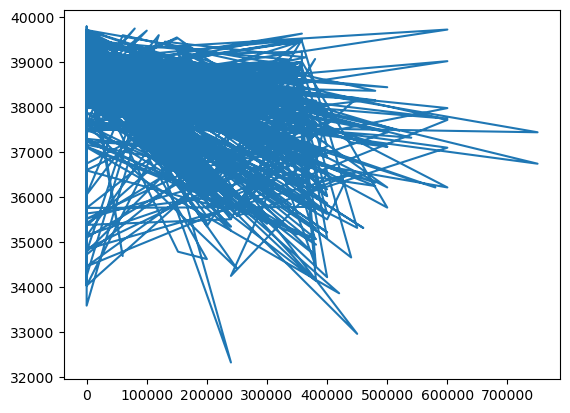

In [118]:
n_treatments = 1

for t in range(n_treatments):
    plt.plot(X_val[:, 1], point[:, t])
    
    if est.inference:
        plt.fill_between(X_val[:, 1], lb[:, t], ub[:, t], alpha=0.4)

plt.show()

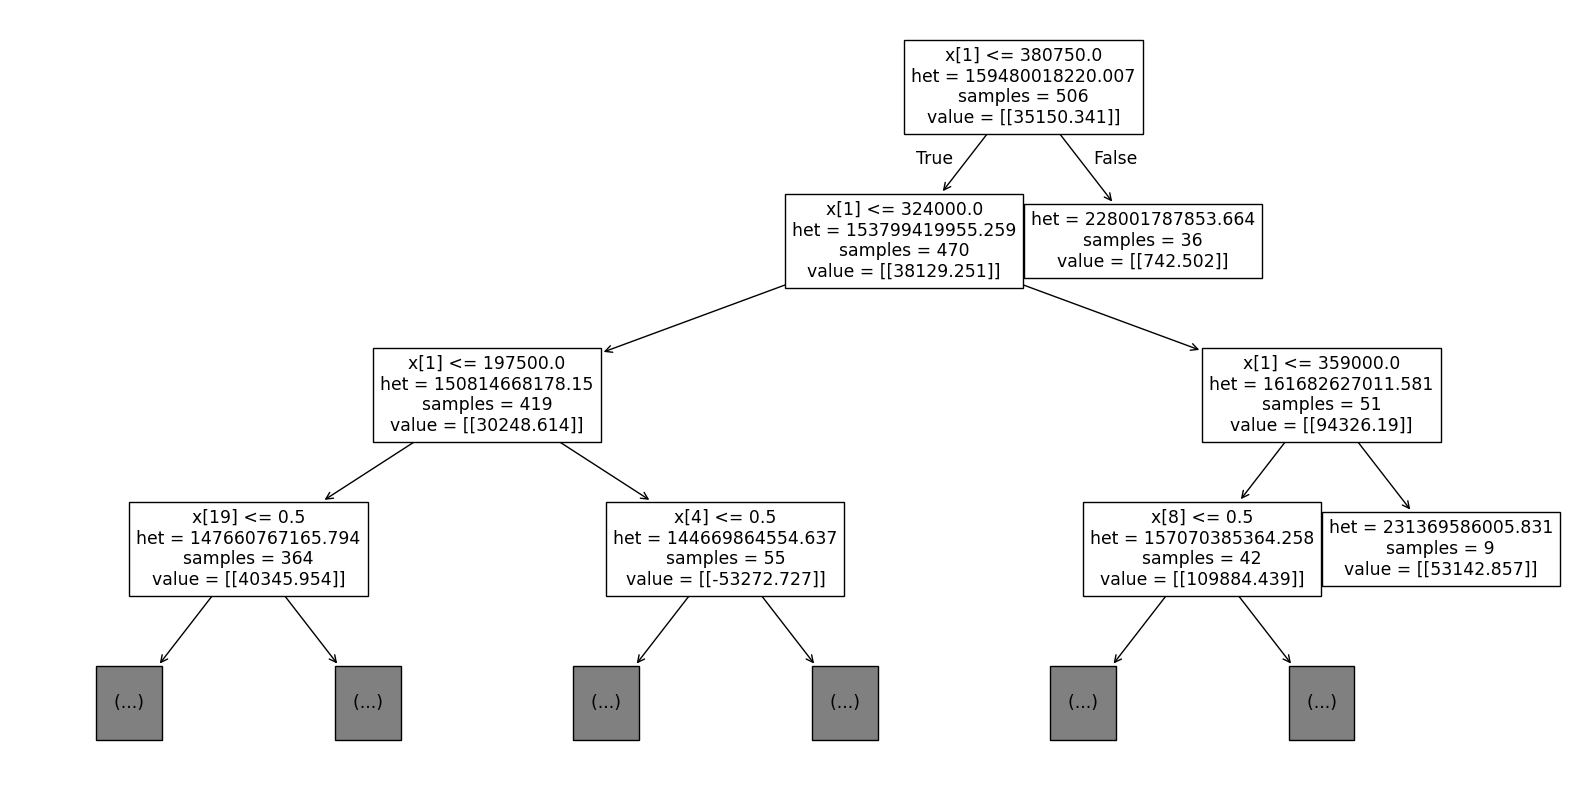

In [119]:
plt.figure(figsize=(20, 10))
plot_tree(est[3], impurity=True, max_depth=3)
plt.show()

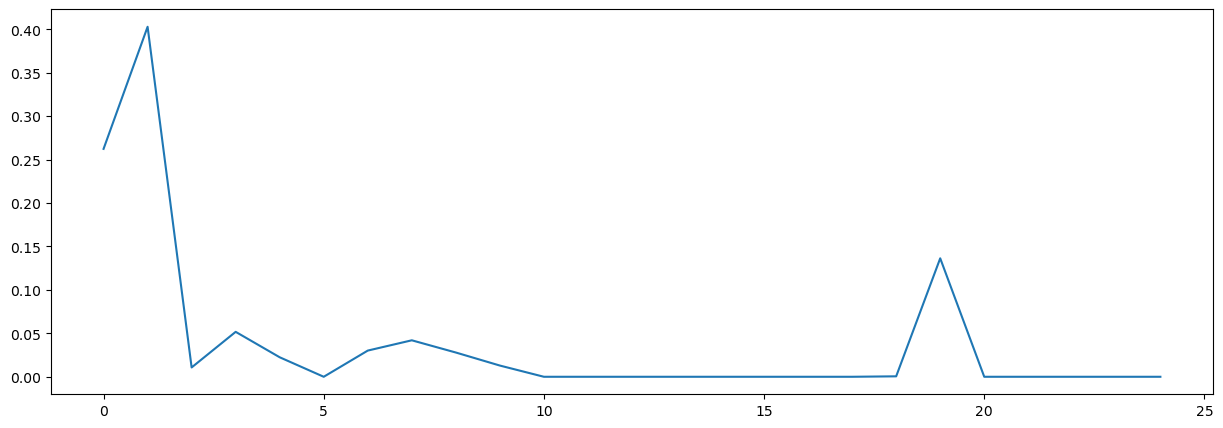

[0.26234483 0.40288979 0.01073151 0.05172778 0.02244075 0.
 0.03014912 0.04198855 0.0279235  0.01291588 0.         0.
 0.         0.         0.         0.         0.         0.
 0.00052187 0.13636642 0.         0.         0.         0.
 0.        ]


In [120]:
plt.figure(figsize=(15,5))
plt.plot(est.feature_importances(max_depth=4, depth_decay_exponent=2.0))
plt.show()
print(est.feature_importances(max_depth=4, depth_decay_exponent=2.0))

In [121]:
import shap
explainer = shap.Explainer(est, shap.maskers.Independent(X, max_samples=100))
shap_values = explainer(X[:200])
shap.plots.beeswarm(shap_values)

Found a NULL input array in _cext_dense_tree_update_weights!


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [122]:
est.decision_path(X_val[:3])

(<Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 1582 stored elements and shape (3, 904)>,
 array([  0,   1,  18,  27,  46,  47,  48,  49,  50,  51,  52,  61,  62,
         63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  75,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97, 104, 105, 106, 107, 108,
        109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 122, 123,
        124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
        147, 164, 181, 182, 185, 186, 187, 188, 189, 190, 191, 192, 193,
        194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 213, 214,
        219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231,
        238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250,
        251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263,
        264, 265, 266, 267, 274, 275, 276, 277, 282, 283, 284, 285, 286,
        287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299,
        300, 301, 30

In [123]:
est.apply(X_val[:3])

array([[ 0, 15,  7, ...,  0,  0,  0],
       [ 0, 15,  7, ...,  0,  0,  0],
       [ 0, 15,  7, ...,  0,  0,  0]], shape=(3, 400))

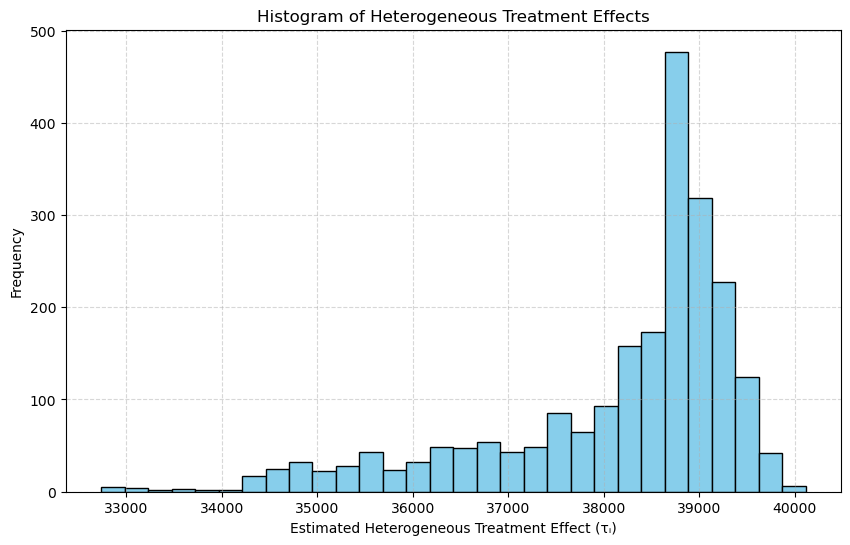

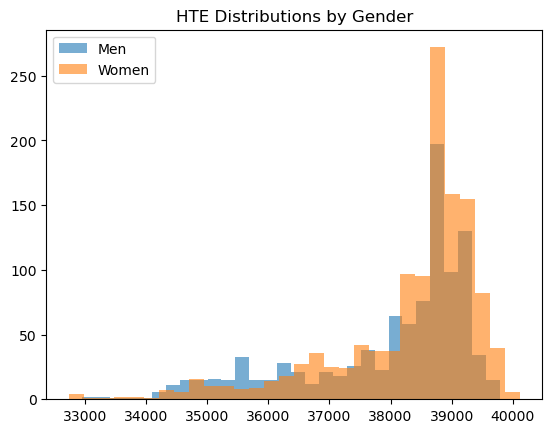

Mean Treatment Effect (ATE): 38143.824894553836
Std of HTE: 1315.5568505314197
Min: 32734.982055598637
Max: 40114.8987732752
Mean Treatment Effect (ATE): 38302.06652064359
Std of HTE: 1219.1425245175
Min: 32734.98205559887
Max: 40114.8987732752
Mean Treatment Effect (ATE): 37948.49784268718
Std of HTE: 1401.1719074129771
Min: 32954.2082610504
Max: 39788.37894982647


In [124]:
hte = est.predict(X_train).ravel()

plt.figure(figsize=(10, 6))
plt.hist(hte, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Estimated Heterogeneous Treatment Effect (τᵢ)")
plt.ylabel("Frequency")
plt.title("Histogram of Heterogeneous Treatment Effects")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

idx_dwomen = feature_cols.index("dwomen")

hte_women = est.predict(X_train[X_train[:, idx_dwomen] == 1]).ravel()
hte_men   = est.predict(X_train[X_train[:, idx_dwomen] == 0]).ravel()

plt.hist(hte_men, bins=30, alpha=0.6, label="Men")
plt.hist(hte_women, bins=30, alpha=0.6, label="Women")
plt.legend()
plt.title("HTE Distributions by Gender")
plt.show()

print("Mean Treatment Effect (ATE):", hte.mean())
print("Std of HTE:", hte.std())
print("Min:", hte.min())
print("Max:", hte.max())

print("Mean Treatment Effect (ATE):", hte_women.mean())
print("Std of HTE:", hte_women.std())
print("Min:", hte_women.min())
print("Max:", hte_women.max())

print("Mean Treatment Effect (ATE):", hte_men.mean())
print("Std of HTE:", hte_men.std())
print("Min:", hte_men.min())
print("Max:", hte_men.max())

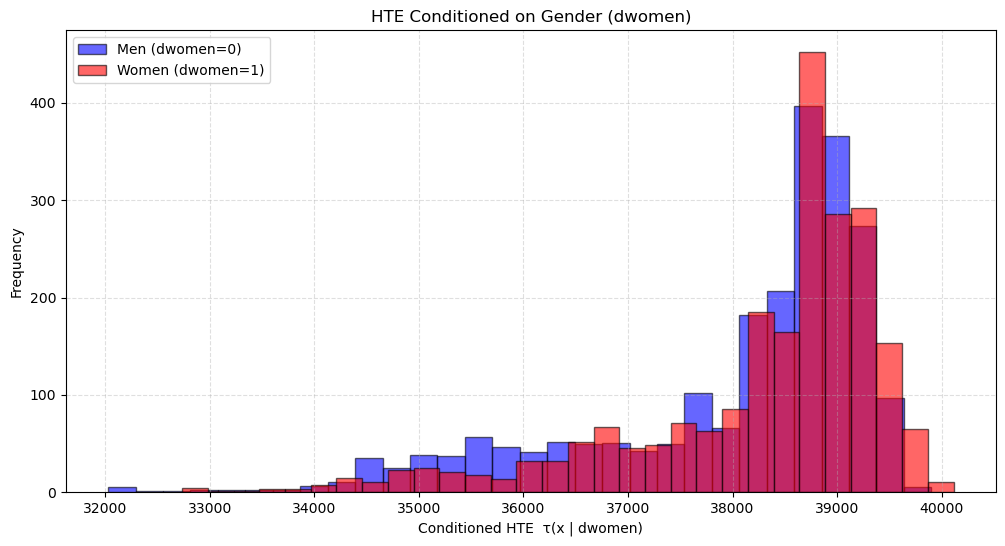

Mean HTE (Men):    38021.75278764444
Mean HTE (Women):  38277.82940996219
Difference:         256.0766223177561

Std HTE (Men):      1361.5597140176978
Std HTE (Women):    1224.9409695606846


In [125]:
# conditioning rather than subsetting

# -----------------------------------------------
# 1. Identify the gender column
# -----------------------------------------------
idx = feature_cols.index("dwomen")

# -----------------------------------------------
# 2. Choose a base sample (same individuals)
# -----------------------------------------------
X_base = X_train[:].copy()   # use 300 for stability; adjust if you want

# -----------------------------------------------
# 3. Create counterfactual gender versions
# -----------------------------------------------
X_men = X_base.copy()
X_men[:, idx] = 0              # force all to 'men'

X_women = X_base.copy()
X_women[:, idx] = 1            # force all to 'women'


# -----------------------------------------------
# 4. Predict treatment effects + CIs
# -----------------------------------------------

# MEN
tau_men = est.predict(X_men).ravel()
lb_m, ub_m = est.predict_interval(X_men)
lb_m = lb_m.ravel()
ub_m = ub_m.ravel()

# WOMEN
tau_women = est.predict(X_women).ravel()
lb_w, ub_w = est.predict_interval(X_women)
lb_w = lb_w.ravel()
ub_w = ub_w.ravel()


# -----------------------------------------------
# 5. Plot histograms of conditioned HTE
# -----------------------------------------------
plt.figure(figsize=(12,6))

plt.hist(tau_men, bins=30, alpha=0.6, label="Men (dwomen=0)", color="blue", edgecolor="black")
plt.hist(tau_women, bins=30, alpha=0.6, label="Women (dwomen=1)", color="red", edgecolor="black")

plt.xlabel("Conditioned HTE  τ(x | dwomen)")
plt.ylabel("Frequency")
plt.title("HTE Conditioned on Gender (dwomen)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


# -----------------------------------------------
# 6. Print summary statistics
# -----------------------------------------------
print("Mean HTE (Men):   ", tau_men.mean())
print("Mean HTE (Women): ", tau_women.mean())
print("Difference:        ", tau_women.mean() - tau_men.mean())

print("\nStd HTE (Men):     ", tau_men.std())
print("Std HTE (Women):   ", tau_women.std())


✓ HTE successfully attached to dataframe.

=== SUBGROUP HTE (Actual Men vs Actual Women) ===
Mean HTE (Women): 38289.444116
Mean HTE (Men):   37965.497153
Difference:       323.946963

=== TEST OF GENDER HETEROGENEITY IN TREATMENT EFFECTS ===
T-statistic: 7.0369
P-value:     0.000000
→ Significant heterogeneity in treatment effects by gender.


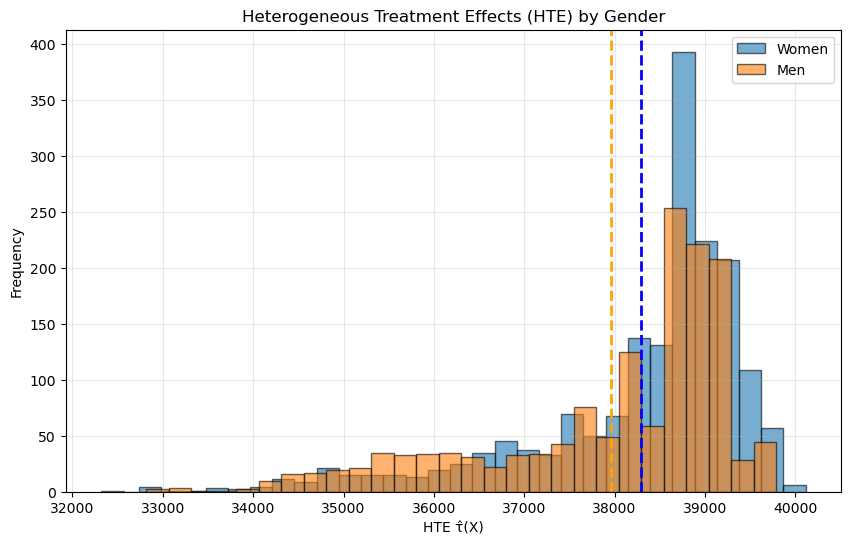


=== QUANTILE COMPARISON OF HTE (Women vs Men) ===
Quantile 10% → Women: 36526.5532, Men: 35660.6113, Diff: 865.9419
Quantile 25% → Women: 37978.8356, Men: 37418.3335, Diff: 560.5021
Quantile 50% → Women: 38695.6109, Men: 38587.0283, Diff: 108.5826
Quantile 75% → Women: 39055.2535, Men: 38915.8548, Diff: 139.3987
Quantile 90% → Women: 39369.5528, Men: 39179.4834, Diff: 190.0694


In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ============================================================
# 1. Predict HTE for each individual using your Causal Forest
# ============================================================

X = data[feature_cols].to_numpy()
data = data.copy()
data["HTE"] = est.predict(X).ravel()

print("✓ HTE successfully attached to dataframe.")


# ============================================================
# 2. Split by gender: ACTUAL MEN vs ACTUAL WOMEN
# ============================================================

hte_women = data.loc[data["dwomen"] == 1, "HTE"]
hte_men   = data.loc[data["dwomen"] == 0, "HTE"]

mean_hte_women = hte_women.mean()
mean_hte_men   = hte_men.mean()
diff_subgroup  = mean_hte_women - mean_hte_men

print("\n=== SUBGROUP HTE (Actual Men vs Actual Women) ===")
print(f"Mean HTE (Women): {mean_hte_women:.6f}")
print(f"Mean HTE (Men):   {mean_hte_men:.6f}")
print(f"Difference:       {diff_subgroup:.6f}")


# ============================================================
# 3. Statistical Test of Heterogeneity
# ============================================================

t_stat, p_value = ttest_ind(hte_women, hte_men, equal_var=False)

print("\n=== TEST OF GENDER HETEROGENEITY IN TREATMENT EFFECTS ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("→ Significant heterogeneity in treatment effects by gender.")
else:
    print("→ No statistically significant heterogeneity detected.")


# ============================================================
# 4. Plot the HTE distributions
# ============================================================

plt.figure(figsize=(10,6))
plt.hist(hte_women, bins=30, alpha=0.6, label="Women", edgecolor='black')
plt.hist(hte_men, bins=30, alpha=0.6, label="Men", edgecolor='black')

plt.axvline(mean_hte_women, color='blue', linestyle='--', linewidth=2)
plt.axvline(mean_hte_men, color='orange', linestyle='--', linewidth=2)

plt.title("Heterogeneous Treatment Effects (HTE) by Gender")
plt.xlabel("HTE τ̂(X)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 5. Quantile comparison (very informative)
# ============================================================

print("\n=== QUANTILE COMPARISON OF HTE (Women vs Men) ===")
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

for q in quantiles:
    print(
        f"Quantile {int(q*100)}% → "
        f"Women: {hte_women.quantile(q):.4f}, "
        f"Men: {hte_men.quantile(q):.4f}, "
        f"Diff: {(hte_women.quantile(q) - hte_men.quantile(q)):.4f}"
    )


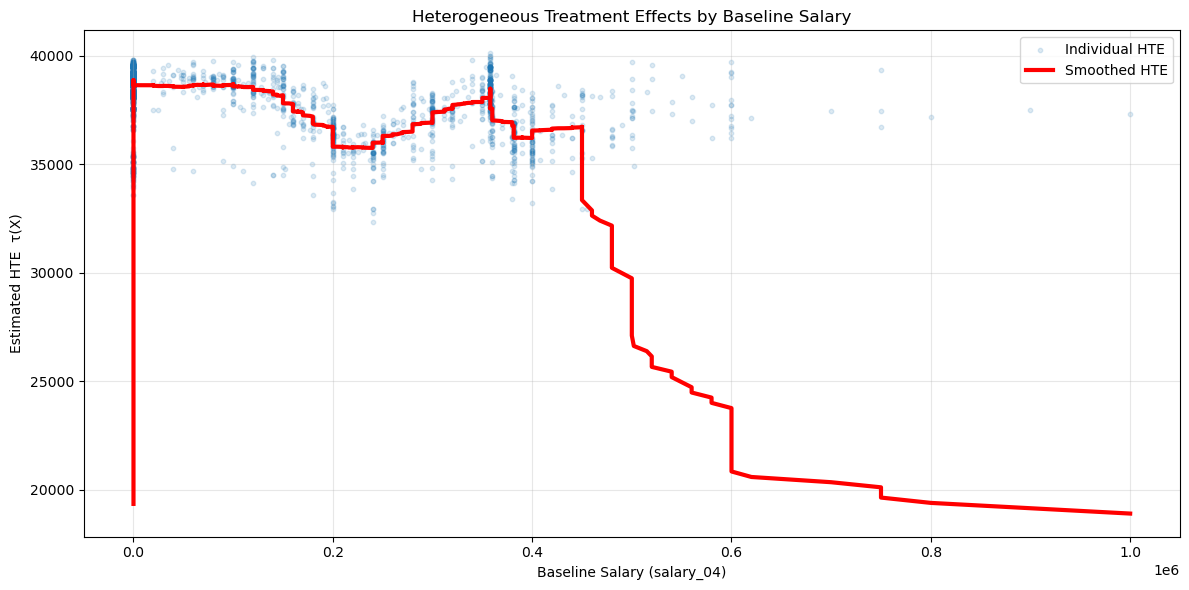

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ----------------------------
# STEP 1: Extract needed data
# ----------------------------
X = data[feature_cols].to_numpy()
tau_hat = data["HTE"].to_numpy()
salary = data["salary_04"].to_numpy()

# ----------------------------
# STEP 2: Sort by salary
# ----------------------------
order = np.argsort(salary)
salary_sorted = salary[order]
hte_sorted = tau_hat[order]

# ----------------------------
# STEP 3: Smooth the HTE curve
# (optional but makes plot nicer)
# ----------------------------
window = 150  # you can change this
hte_smooth = np.convolve(hte_sorted, 
                         np.ones(window)/window,
                         mode='same')

# ----------------------------
# STEP 4: Plot
# ----------------------------
plt.figure(figsize=(12,6))

plt.scatter(salary_sorted, hte_sorted,
            alpha=0.15, s=10, label='Individual HTE')

plt.plot(salary_sorted, hte_smooth,
         color='red', linewidth=3, 
         label='Smoothed HTE')

plt.xlabel("Baseline Salary (salary_04)")
plt.ylabel("Estimated HTE  τ(X)")
plt.title("Heterogeneous Treatment Effects by Baseline Salary")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


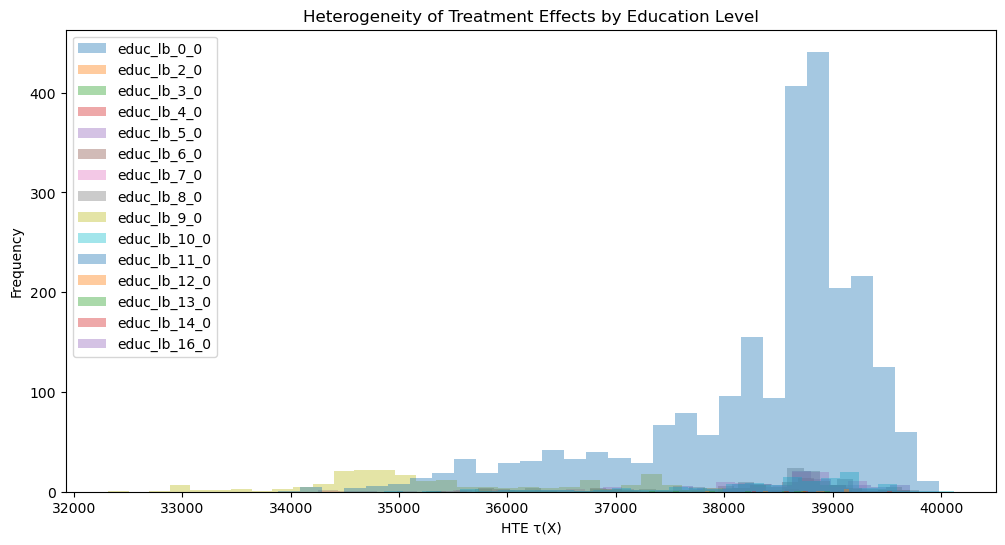

In [130]:
import matplotlib.pyplot as plt

education_cols = [c for c in data.columns if "educ_lb_" in c]

plt.figure(figsize=(12,6))

for col in education_cols:
    subset = data[data[col] == 1]
    plt.hist(subset["HTE"], bins=30, alpha=0.4, label=col)

plt.xlabel("HTE τ(X)")
plt.ylabel("Frequency")
plt.title("Heterogeneity of Treatment Effects by Education Level")
plt.legend()
plt.show()


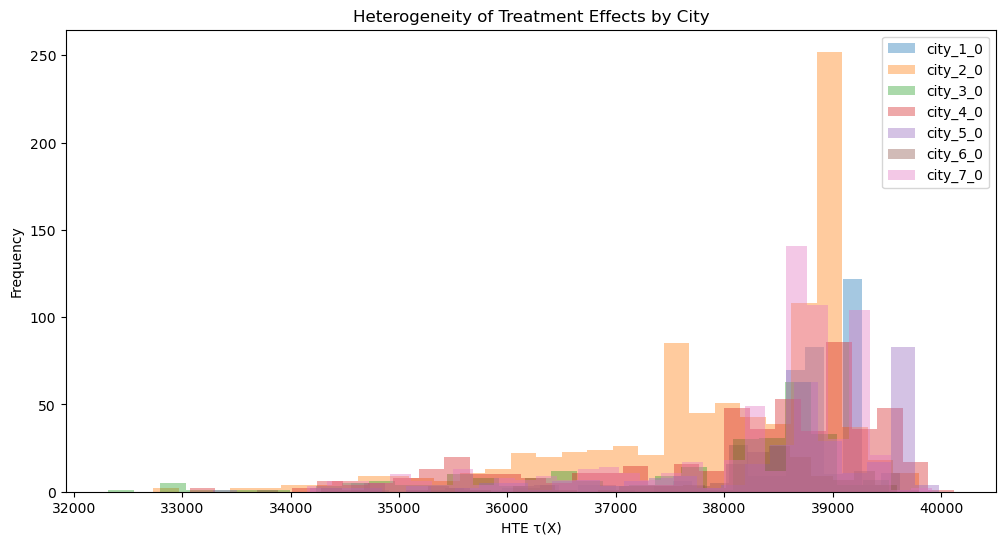

In [131]:
city_cols = [c for c in data.columns if "city_" in c]

plt.figure(figsize=(12,6))

for col in city_cols:
    subset = data[data[col] == 1]
    plt.hist(subset["HTE"], bins=30, alpha=0.4, label=col)

plt.xlabel("HTE τ(X)")
plt.ylabel("Frequency")
plt.title("Heterogeneity of Treatment Effects by City")
plt.legend()
plt.show()


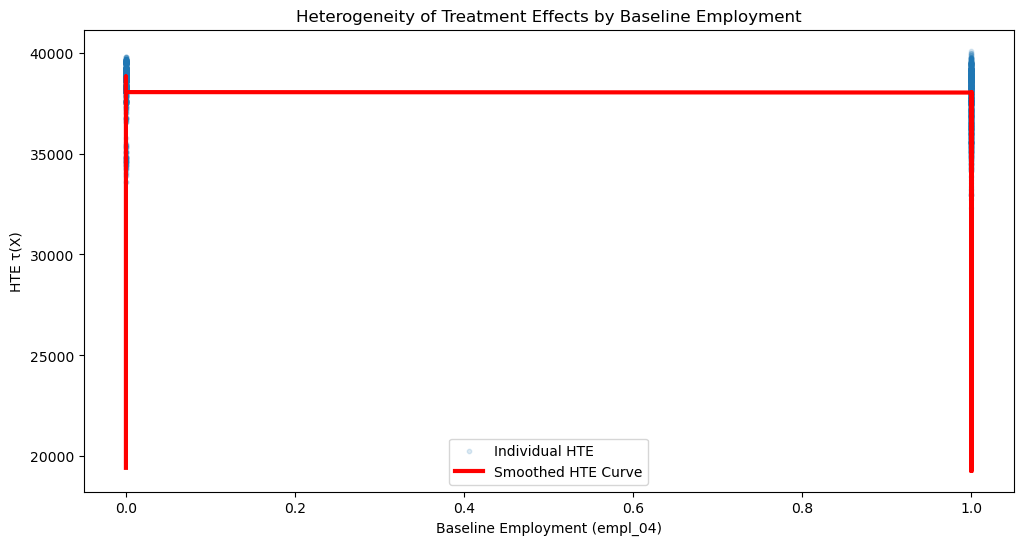

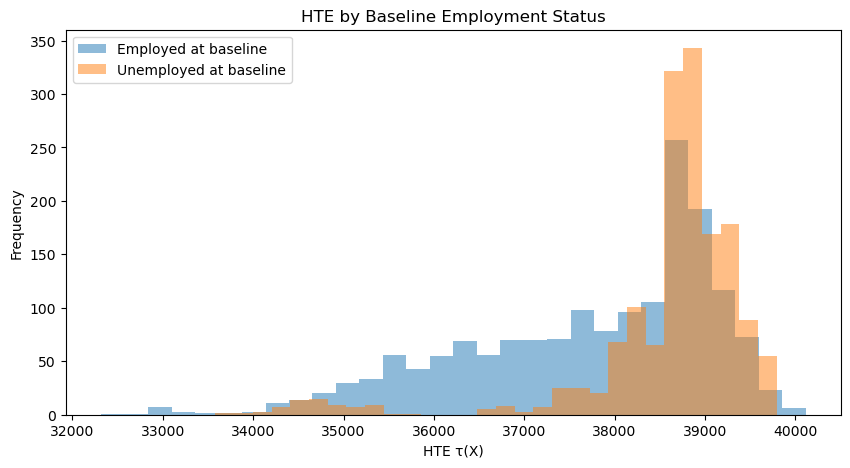

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# Continuous heterogeneity curve
X_vals = data["empl_04"].to_numpy()
hte_vals = data["HTE"].to_numpy()

order = np.argsort(X_vals)
x_sorted = X_vals[order]
hte_sorted = hte_vals[order]

window = 150
hte_smooth = np.convolve(hte_sorted, np.ones(window)/window, mode='same')

plt.figure(figsize=(12,6))
plt.scatter(x_sorted, hte_sorted, alpha=0.15, s=10, label='Individual HTE')
plt.plot(x_sorted, hte_smooth, color='red', linewidth=3, label='Smoothed HTE Curve')

plt.xlabel("Baseline Employment (empl_04)")
plt.ylabel("HTE τ(X)")
plt.title("Heterogeneity of Treatment Effects by Baseline Employment")
plt.legend()
plt.show()

# Binary comparison (employed vs unemployed)
plt.figure(figsize=(10,5))
plt.hist(data.loc[data["empl_04"]==1, "HTE"], bins=30, alpha=0.5, label="Employed at baseline")
plt.hist(data.loc[data["empl_04"]==0, "HTE"], bins=30, alpha=0.5, label="Unemployed at baseline")

plt.xlabel("HTE τ(X)")
plt.ylabel("Frequency")
plt.title("HTE by Baseline Employment Status")
plt.legend()
plt.show()


## 2. Causal IV Forest: Heterogeneous causal effects with unobserved confounders

In [29]:
# define a baseline employment indicator
data["baseline_emp"] = (data["empl_04"] > 0).astype(int)

hte_hi = data.loc[data["baseline_emp"] == 1, "HTE"]
hte_lo = data.loc[data["baseline_emp"] == 0, "HTE"]

print("Mean HTE, baseline employed:", hte_hi.mean())
print("Mean HTE, baseline not employed:", hte_lo.mean())
print("Difference (emp - not):", hte_hi.mean() - hte_lo.mean())


Mean HTE, baseline employed: 0.03706948487693466
Mean HTE, baseline not employed: 0.039038072246983295
Difference (emp - not): -0.0019685873700486384


In [13]:
np.random.seed(1227)
n_samples = 2000
n_features = 10
n_treatments = 2
# true_te = lambda X: np.hstack([X[:, [0]]**2 + 1, np.ones((X.shape[0], n_treatments - 1))])
def true_te(X):
    return np.hstack([X[:, [0]] > 0, np.ones((X.shape[0], n_treatments - 1))])
# true_te = lambda X: np.hstack([(X[:, [0]]>0) * X[:, [0]],
#                                np.ones((X.shape[0], n_treatments - 1))*np.arange(1, n_treatments).reshape(1, -1)])
Z = np.random.normal(0, 1, size=(n_samples, n_treatments))
X = np.random.normal(0, 1, size=(n_samples, n_features))
U = np.random.normal(0, .2, size=(n_samples, 1))
T = np.random.normal(0, 1, size=(n_samples, n_treatments))
for t in range(n_treatments):
    T[:, t] += U[:, 0] + Z[:, t]
y = np.sum(true_te(X) * T, axis=1, keepdims=True) + 10 * U[:, [0]]
X_test = X[:1000].copy()
X_test[:, 0] = np.linspace(np.percentile(X[:, 0], 1), np.percentile(X[:, 0], 99), 1000)

In [35]:
median_wage = data["salary_04"].median()
data["high_wage"] = (data["salary_04"] > median_wage).astype(int)


hte_high = data.loc[data["high_wage"]==1, "HTE"]
hte_low  = data.loc[data["high_wage"]==0, "HTE"]

print("Mean HTE high wage:", hte_high.mean())
print("Mean HTE low wage:", hte_low.mean())
print("Difference:", hte_high.mean() - hte_low.mean())


Mean HTE high wage: 0.03628354533337919
Mean HTE low wage: 0.039015449354032984
Difference: -0.0027319040206537915


In [31]:
low_educ_cols  = ["educ_lb_0_0","educ_lb_2_0","educ_lb_3_0","educ_lb_4_0","educ_lb_5_0","educ_lb_6_0","educ_lb_7_0","educ_lb_8_0"]
high_educ_cols = ["educ_lb_9_0","educ_lb_10_0","educ_lb_12_0","educ_lb_13_0","educ_lb_14_0","educ_lb_16_0"]

data["low_educ"]  = (data[low_educ_cols].sum(axis=1)  == 1).astype(int)
data["high_educ"] = (data[high_educ_cols].sum(axis=1) == 1).astype(int)

hte_low  = data.loc[data["low_educ"] == 1,  "HTE"]
hte_high = data.loc[data["high_educ"] == 1, "HTE"]

print("Mean HTE, low education:", hte_low.mean())
print("Mean HTE, high education:", hte_high.mean())
print("Difference (low - high):", hte_low.mean() - hte_high.mean())


Mean HTE, low education: 0.0381243610710632
Mean HTE, high education: 0.03608690192471897
Difference (low - high): 0.002037459146344227


In [32]:
city_cols = ["city_1_0","city_2_0","city_3_0","city_4_0","city_5_0","city_6_0","city_7_0"]

for c in city_cols:
    print(c, "mean HTE:", data.loc[data[c] == 1, "HTE"].mean())


city_1_0 mean HTE: 0.03883623985938037
city_2_0 mean HTE: 0.03731003492660422
city_3_0 mean HTE: 0.03704122193539422
city_4_0 mean HTE: 0.038258772015181776
city_5_0 mean HTE: 0.0393744784775553
city_6_0 mean HTE: 0.038210457384314514
city_7_0 mean HTE: 0.03803338604317575


In [14]:
est = CausalIVForest(criterion='mse', n_estimators=400, min_samples_leaf=40,
                     min_var_fraction_leaf=0.1, min_var_leaf_on_val=True,
                     min_impurity_decrease = 0.001, max_samples=.45, max_depth=None,
                     warm_start=False, inference=True, subforest_size=4,
                     honest=True, verbose=0, n_jobs=-1, random_state=123)

In [15]:
est.fit(X, T, y, Z=Z)

CausalIVForest(min_impurity_decrease=0.001, min_samples_leaf=40,
               min_var_fraction_leaf=0.1, min_var_leaf_on_val=True,
               n_estimators=400, random_state=123)

In [16]:
point, lb, ub = est.predict(X_test, interval=True, alpha=0.01)

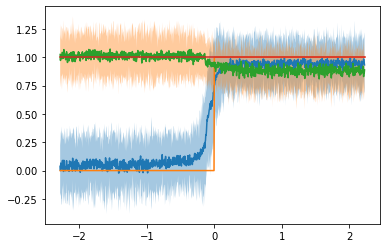

In [17]:
for t in range(n_treatments):
    plt.plot(X_test[:, 0], point[:, t])
    if est.inference:
        plt.fill_between(X_test[:, 0], lb[:, t], ub[:, t], alpha=.4)
    plt.plot(X_test[:, 0], true_te(X_test)[:, t])
plt.show()

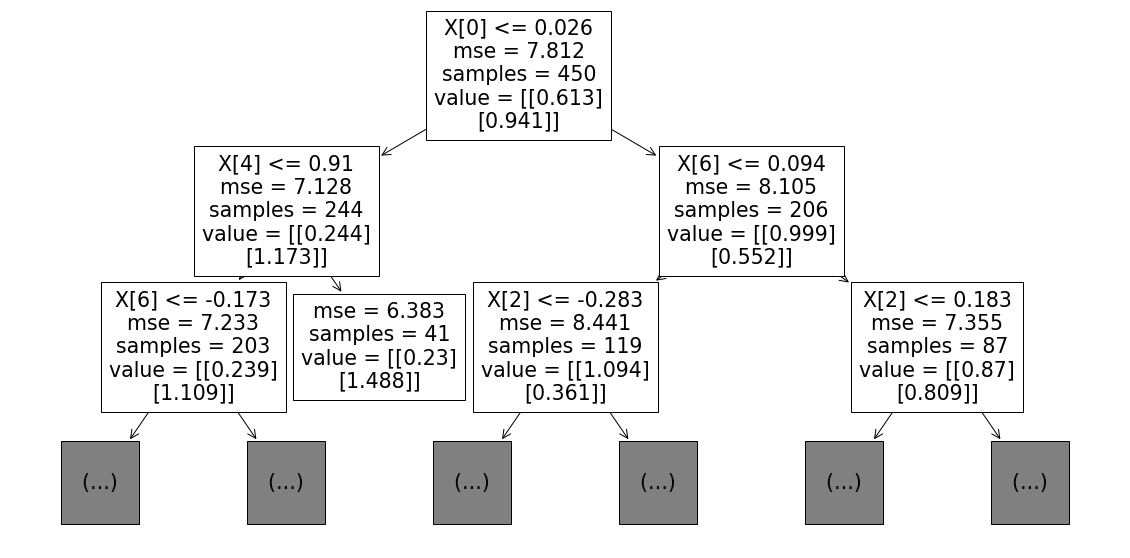

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(est[0], impurity=True, max_depth=2)
plt.show()

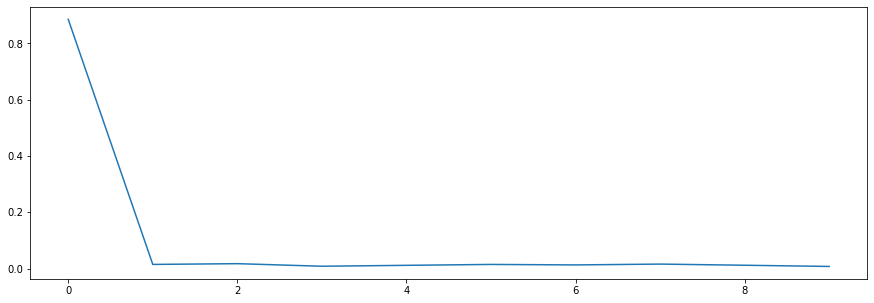

In [19]:
plt.figure(figsize=(15,5))
plt.plot(est.feature_importances(max_depth=4, depth_decay_exponent=2.0))
plt.show()

In [20]:
import shap
explainer = shap.Explainer(est, shap.maskers.Independent(X, max_samples=100))
shap_values = explainer(X[:200])

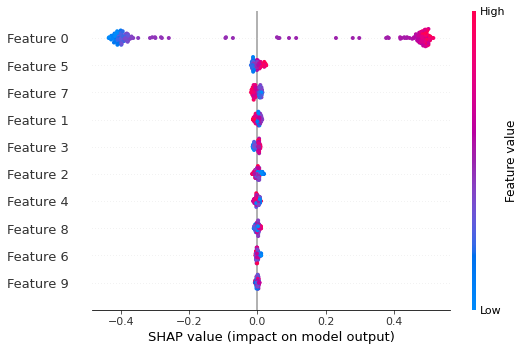

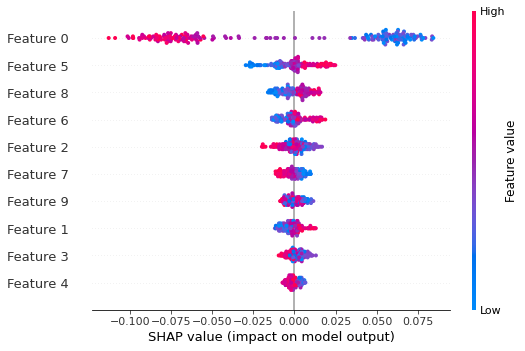

In [21]:
shap.plots.beeswarm(shap_values[:, :, 0])
shap.plots.beeswarm(shap_values[:, :, 1])

In [22]:
est[0].decision_path(X_test[:1])

<1x15 sparse matrix of type '<class 'numpy.int64'>'
	with 4 stored elements in Compressed Sparse Row format>

In [23]:
est[0].apply(X_test[:1])

array([3], dtype=int64)

## 3. Regression Forest: Random Forest Regressor with confidence intervals

In [24]:
np.random.seed(123)
n_samples = 2000
n_features = 10
n_outputs = 2
def true_te(X):
    return np.hstack([X[:, [0]] ** 2 + 1, np.ones((X.shape[0], n_outputs - 1))])
# true_te = lambda X: np.hstack([X[:, [0]]>0, np.ones((X.shape[0], n_outputs - 1))])
# true_te = lambda X: np.hstack([(X[:, [0]]>0) * X[:, [0]],
#                                np.ones((X.shape[0], n_outputs - 1))*np.arange(1, n_outputs).reshape(1, -1)])
X = np.random.normal(0, 1, size=(n_samples, n_features))
y = true_te(X) + 0.0 * X[:, [0]] + np.random.normal(0, .1, size=(n_samples, 1))
X_test = X[:min(100, n_samples)].copy()
X_test[:, 0] = np.linspace(np.percentile(X[:, 0], 1), np.percentile(X[:, 0], 99), min(100, n_samples))

In [25]:
est = RegressionForest(n_estimators=400, min_samples_leaf=5, max_depth=None,
                       min_impurity_decrease = 0.0, max_samples=0.45, min_balancedness_tol=.45,
                       warm_start=False, inference=True, subforest_size=4,
                       honest=True, verbose=0, n_jobs=-1, random_state=1235)

In [26]:
est.fit(X, y)

RegressionForest(n_estimators=400, random_state=1235)

In [27]:
point, lb, ub = est.predict(X_test, interval=True, alpha=0.01)

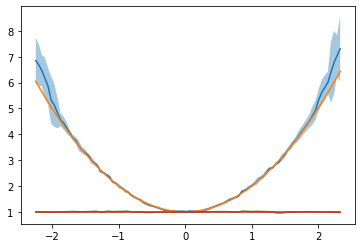

In [28]:
for t in range(n_outputs):
    plt.plot(X_test[:, 0], point[:, t])
    if est.inference:
        plt.fill_between(X_test[:, 0], lb[:, t], ub[:, t], alpha=.4)
    plt.plot(X_test[:, 0], true_te(X_test)[:, t])
plt.show()

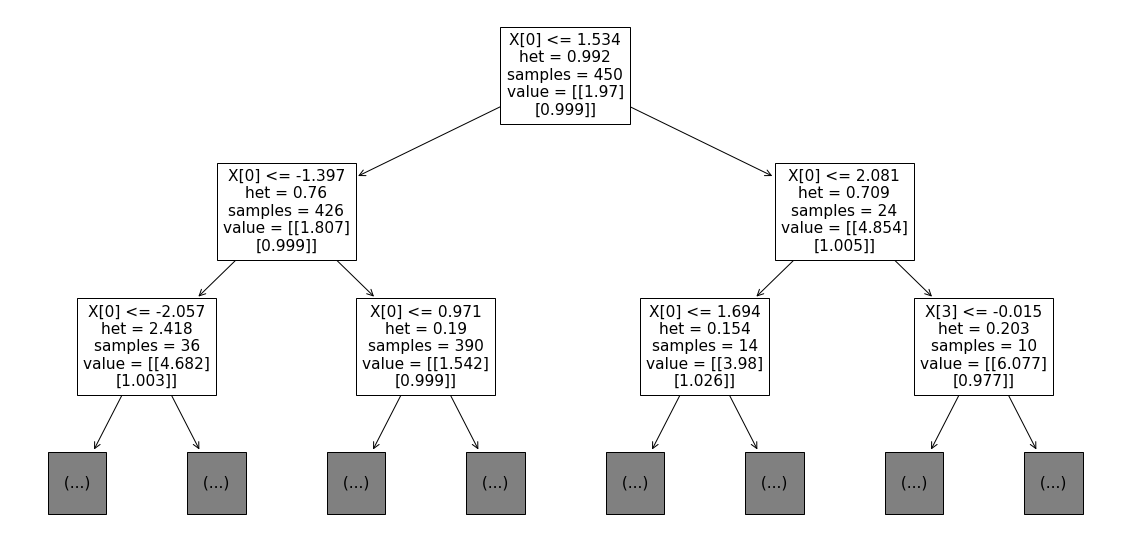

In [29]:
plt.figure(figsize=(20, 10))
plot_tree(est[0], impurity=True, max_depth=2)
plt.show()

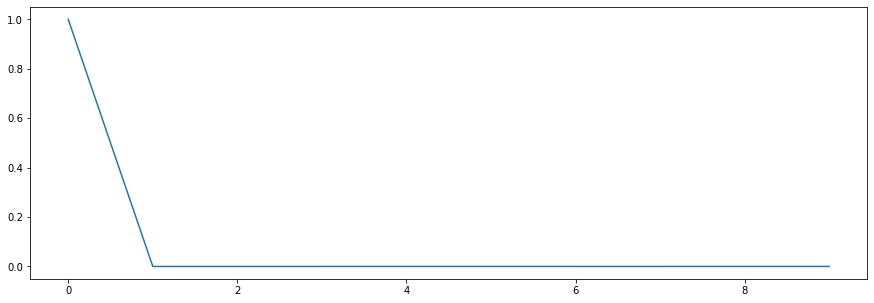

In [30]:
plt.figure(figsize=(15,5))
plt.plot(est.feature_importances(max_depth=4, depth_decay_exponent=2.0))
plt.show()

In [31]:
import shap
explainer = shap.Explainer(est, shap.maskers.Independent(X, max_samples=100))
shap_values = explainer(X[:200])

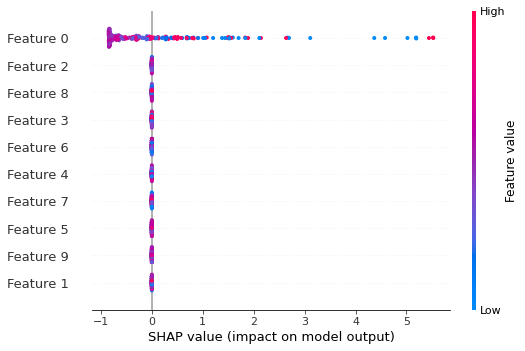

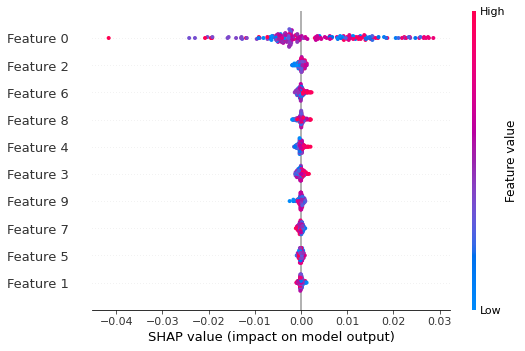

In [32]:
shap.plots.beeswarm(shap_values[:, :, 0])
shap.plots.beeswarm(shap_values[:, :, 1])

## 4. Combining with Double Machine Learning

In [33]:
np.random.seed(123)
n_samples = 5000
n_features = 10
n_treatments = 3
n_outputs = 2
# true_te = lambda X: np.hstack([X[:, [0]]**2 + 1, np.ones((X.shape[0], n_treatments - 1))])
# true_te = lambda X: np.hstack([X[:, [0]]>0, np.ones((X.shape[0], n_treatments - 1))])
def true_te(X):
    return np.hstack([(X[:, [0]] > 0) * X[:, [0]],
                      np.ones((X.shape[0], n_treatments - 1)) * np.arange(1, n_treatments).reshape(1, -1)])
X = np.random.normal(0, 1, size=(n_samples, n_features))
W = np.random.normal(0, 1, size=(n_samples, n_features))
T = np.random.normal(0, 1, size=(n_samples, n_treatments))
for t in range(n_treatments):
    T[:, t] = np.random.binomial(1, scipy.special.expit(X[:, 0]))
y = np.sum(true_te(X) * T, axis=1, keepdims=True) + 5.0 * X[:, [0]] + np.random.normal(0, .1, size=(n_samples, 1))
y = np.tile(y, (1, n_outputs))
for j in range(n_outputs):
    y[:, j] = (j + 1) * y[:, j]
X_test = X[:min(100, n_samples)].copy()
X_test[:, 0] = np.linspace(np.percentile(X[:, 0], 1), np.percentile(X[:, 0], 99), min(100, n_samples))

In [34]:
est = CausalForestDML(cv=2,
                      criterion='mse', n_estimators=400,
                      min_var_fraction_leaf=0.1,
                      min_var_leaf_on_val=True,
                      verbose=0, discrete_treatment=False,
                      n_jobs=-1, random_state=123)
%time est.fit(y, T, X=X, W=W)

Wall time: 11.3 s


In [35]:
res = est.const_marginal_effect_inference(X_test)
point = res.point_estimate
lb, ub = res.conf_int(alpha=.01)

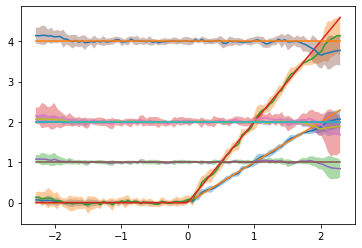

In [36]:
for t in range(n_treatments):
    for j in range(n_outputs):
        plt.plot(X_test[:, 0], point[:, j, t])
        plt.fill_between(X_test[:,0], lb[:, j, t], ub[:, j, t], alpha=.4)
        plt.plot(X_test[:, 0], (j + 1) * true_te(X_test)[:, t])
plt.show()

In [37]:
res.summary_frame()

point_estimate  stderr   zstat  pvalue  ci_lower  ci_upper
X  Y  T                                                             
0  Y0 T0           0.066   0.025   2.660   0.008     0.025     0.107
      T1           1.077   0.040  26.652   0.000     1.011     1.144
      T2           2.071   0.039  53.520   0.000     2.007     2.134
   Y1 T0           0.132   0.050   2.660   0.008     0.050     0.213
      T1           2.155   0.081  26.652   0.000     2.022     2.288
...                  ...     ...     ...     ...       ...       ...
99 Y0 T1           0.842   0.087   9.706   0.000     0.699     0.985
      T2           1.887   0.074  25.641   0.000     1.766     2.008
   Y1 T0           4.139   0.187  22.148   0.000     3.832     4.447
      T1           1.684   0.174   9.706   0.000     1.399     1.970
      T2           3.774   0.147  25.641   0.000     3.532     4.016

[600 rows x 6 columns]

In [38]:
res = est.effect_inference(X_test,
                           T0=np.zeros((X_test.shape[0], n_treatments)),
                           T1=np.ones((X_test.shape[0], n_treatments)))
point = res.point_estimate
lb, ub = res.conf_int(alpha=0.01)

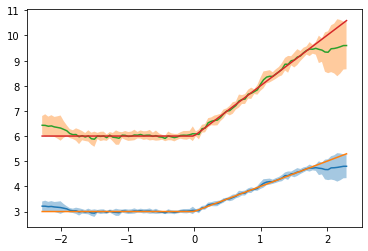

In [39]:
for j in range(n_outputs):
    plt.plot(X_test[:, 0], point[:, j])
    plt.fill_between(X_test[:,0], lb[:, j], ub[:, j], alpha=.4)
    plt.plot(X_test[:, 0], (j + 1) * np.sum(true_te(X_test), axis=1))
plt.show()

In [40]:
res.summary_frame()

point_estimate  stderr   zstat  pvalue  ci_lower  ci_upper
X  Y                                                             
0  Y0           3.214   0.072  44.951     0.0     3.097     3.332
   Y1           6.428   0.143  44.951     0.0     6.193     6.663
1  Y0           3.212   0.086  37.447     0.0     3.071     3.353
   Y1           6.424   0.172  37.447     0.0     6.142     6.706
2  Y0           3.194   0.074  43.012     0.0     3.072     3.317
...               ...     ...     ...     ...       ...       ...
97 Y1           9.551   0.413  23.151     0.0     8.872    10.229
98 Y0           4.798   0.185  25.954     0.0     4.494     5.102
   Y1           9.596   0.370  25.954     0.0     8.988    10.204
99 Y0           4.799   0.183  26.212     0.0     4.497     5.100
   Y1           9.597   0.366  26.212     0.0     8.995    10.199

[200 rows x 6 columns]

In [41]:
est.feature_importances_

array([[0.98217628, 0.00347145, 0.00153771, 0.00260605, 0.00102379,
        0.00138967, 0.00223861, 0.00133064, 0.0030675 , 0.00115831],
       [0.98217628, 0.00347145, 0.00153771, 0.00260605, 0.00102379,
        0.00138967, 0.00223861, 0.00133064, 0.0030675 , 0.00115831]])

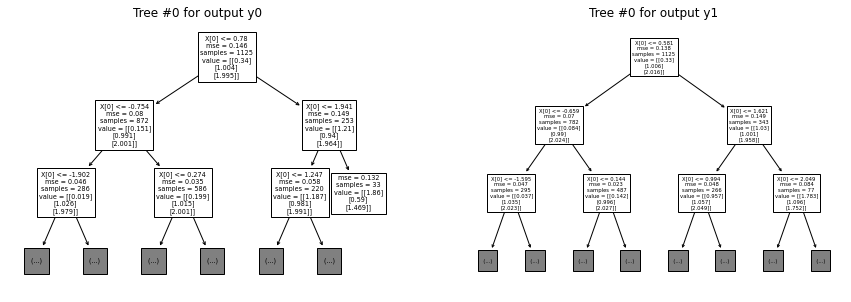

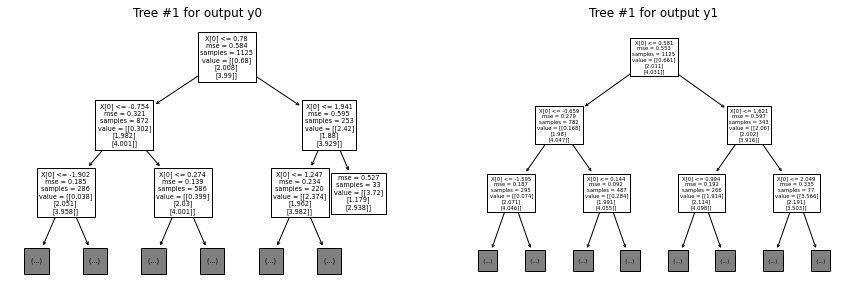

In [42]:
for tree_id, tree_per_output in enumerate(est[:2]):
    plt.figure(figsize=(15, 5))
    for j in range(n_outputs):
        plt.subplot(1, n_outputs, j + 1)
        plot_tree(tree_per_output[j], max_depth=2)
        plt.title("Tree #{} for output y{}".format(tree_id, j))
    plt.show()

In [43]:
est[0]

[GRFTree(max_features='auto', min_var_leaf=0.020617404788809485,
         min_var_leaf_on_val=True, random_state=914636141),
 GRFTree(max_features='auto', min_var_leaf=0.020617404788809485,
         min_var_leaf_on_val=True, random_state=914636141)]

In [44]:
import shap
shap_values = est.shap_values(X[:20])

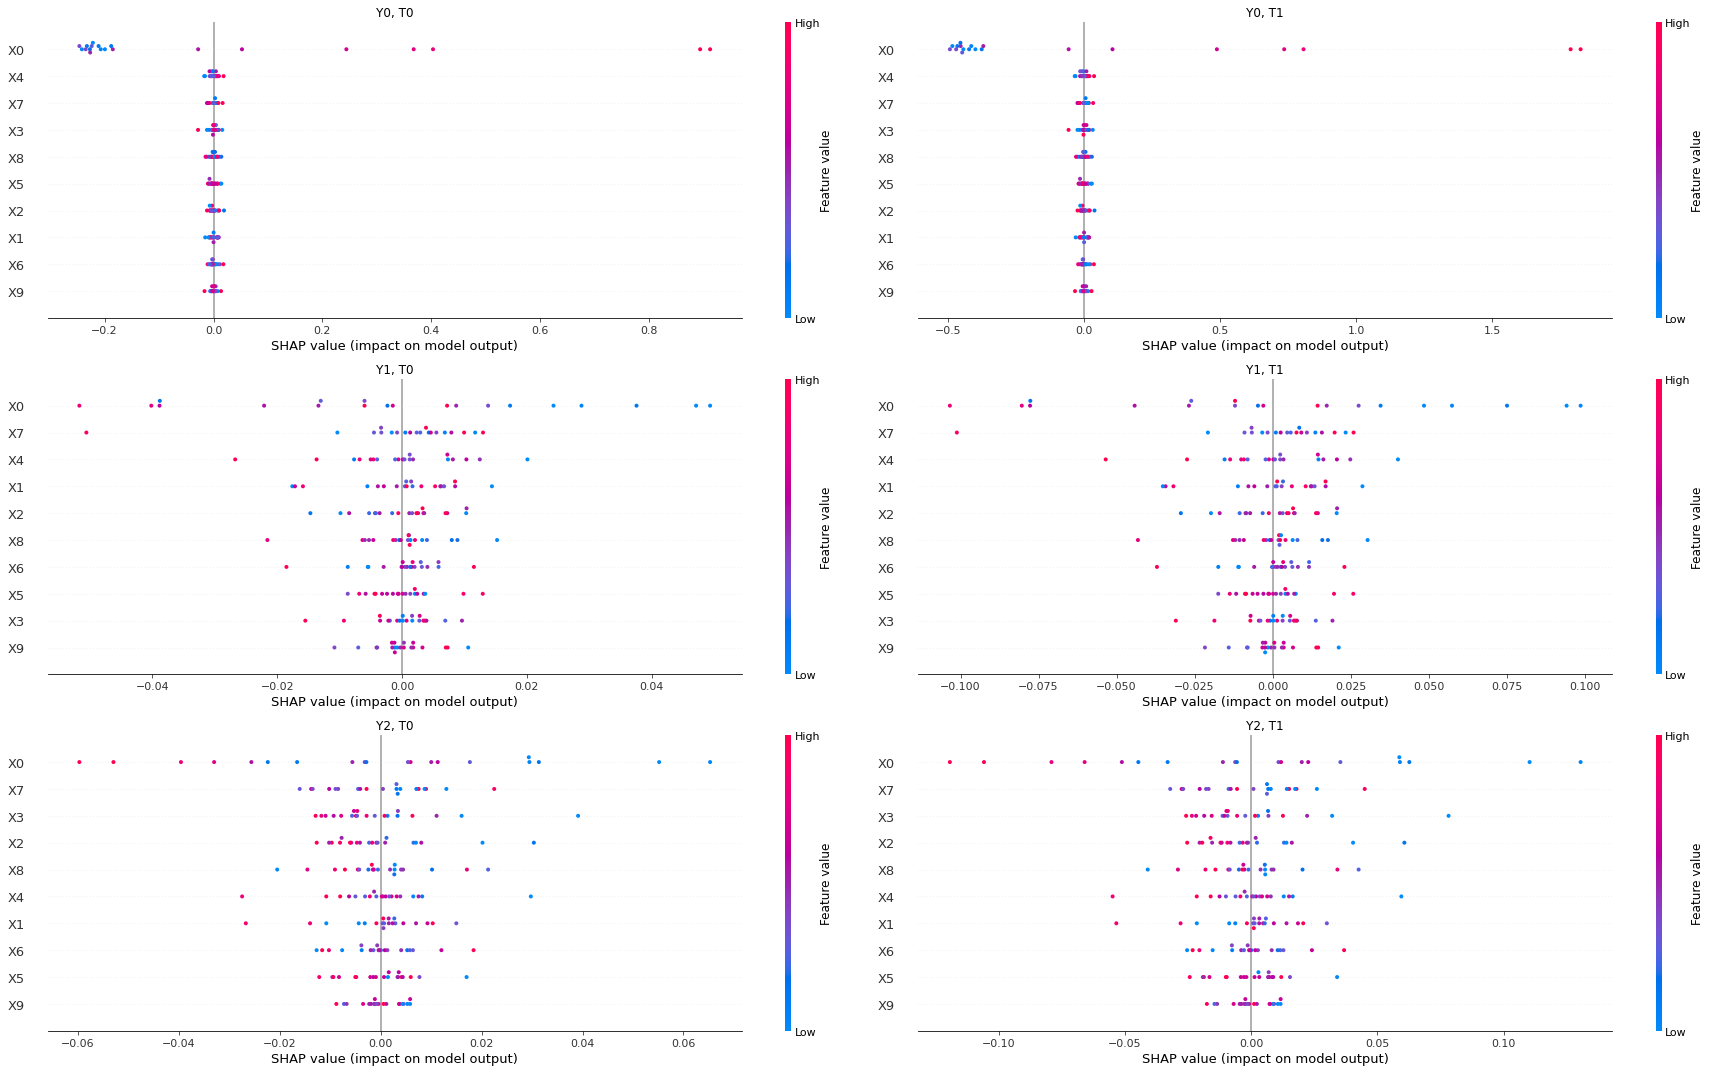

In [45]:
plt.figure(figsize=(25, 15))
for j in range(n_treatments):
    for i in range(n_outputs):
        plt.subplot(n_treatments, n_outputs, i + j * n_outputs + 1)
        plt.title("Y{}, T{}".format(j, i))
        shap.plots.beeswarm(shap_values['Y' + str(i)]['T' + str(j)], plot_size=None, show=False)
plt.tight_layout()
plt.show()

# 5. Custom Linear Moment Forest

We can even easily create an estimator class that solves a customer linear moment that we want to define on the fly. The `BaseGRF` class can handle the estimation of any linear moment problem of the form:
\begin{equation}
E[\text{pointJ} \cdot (\theta(x); \beta(x)) - \alpha \mid X=x] = 0
\end{equation}

The user simply needs to create a child class that inherits from the `BaseGRF` and implement the abstract methods `_get_alpha_and_pointJ` and `_get_n_outputs_decomposition`. The first function takes as input all the variables passed at fit time (i.e. `X`, `T`, `y`, and any other keyword based variables the user passes) and returns for each sample the $\alpha$ vector of the linear moment and a flattened version of the $\text{pointJ}$ matrix in the linear moment (in Fortran contiguous form, i.e. the first row is first, the second row next etc). The second function returns two numbers, the first number corresponds to the size of the concatenated parameter vector $(\theta(x); \beta(x))$ and the second number corresponds to the size of the prefix $\theta(x)$ that we care about ($\beta(x)$ is a nuisance parameter).

As a simple expository example let's see how we can create a forest that solves a moment of the form:
\begin{equation}
E[(y - \theta(x)' (T; T^2)) (Z; Z^2) \mid X=x]
\end{equation}
i.e. where we expand the treatments and instruments to include their squares and solve this quadratic in treatment heterogenous IV model.

In [46]:
np.random.seed(1227)
n_samples = 2000
n_features = 10
n_treatments = 2
def true_te(X):
    return np.hstack([X[:, [0]] > 0, np.ones((X.shape[0], n_treatments - 1))])
Z = np.random.normal(0, 1, size=(n_samples, n_treatments))
X = np.random.normal(0, 1, size=(n_samples, n_features))
U = np.random.normal(0, .2, size=(n_samples, 1))
T = np.random.normal(0, 1, size=(n_samples, n_treatments))
for t in range(n_treatments):
    T[:, t] += U[:, 0] + Z[:, t]
y = np.sum(true_te(X) * T, axis=1, keepdims=True) + 10 * U[:, [0]]
X_test = X[:1000].copy()
X_test[:, 0] = np.linspace(np.percentile(X[:, 0], 1), np.percentile(X[:, 0], 99), 1000)

In [47]:
from econml.grf._base_grf import BaseGRF
from econml.utilities import cross_product

class CustomGRF(BaseGRF):

    def _get_alpha_and_pointJ(self, X, T, y, *, Z):
        T = np.hstack([T, T**2])
        Z = np.hstack([Z, Z**2])
        if self.fit_intercept:
            T = np.hstack([T, np.ones((T.shape[0], 1))])
            Z = np.hstack([Z, np.ones((T.shape[0], 1))])
        return y * Z, cross_product(Z, T)


    def _get_n_outputs_decomposition(self, X, T, y, *, Z):
        n_relevant_outputs = T.shape[1] * 2
        n_outputs = n_relevant_outputs
        if self.fit_intercept:
            n_outputs += 1
        return n_outputs, n_relevant_outputs

In [48]:
est = CustomGRF(criterion='mse', n_estimators=400, min_samples_leaf=40,
                     min_var_fraction_leaf=0.1, min_var_leaf_on_val=True,
                     min_impurity_decrease = 0.001, max_samples=.45, max_depth=None,
                     warm_start=False, inference=True, subforest_size=4,
                     honest=True, verbose=0, n_jobs=-1, random_state=123)

In [49]:
est.fit(X, T, y, Z=Z)

CustomGRF(min_impurity_decrease=0.001, min_samples_leaf=40,
          min_var_fraction_leaf=0.1, min_var_leaf_on_val=True, n_estimators=400,
          random_state=123)

In [50]:
point, lb, ub = est.predict(X_test, interval=True, alpha=0.01)

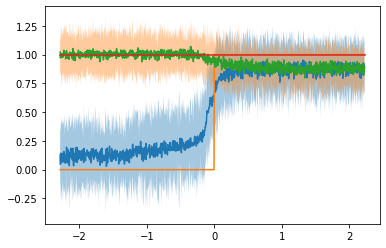

In [51]:
for t in range(n_outputs):
    plt.plot(X_test[:, 0], point[:, t])
    if est.inference:
        plt.fill_between(X_test[:, 0], lb[:, t], ub[:, t], alpha=.4)
    plt.plot(X_test[:, 0], true_te(X_test)[:, t])
plt.show()

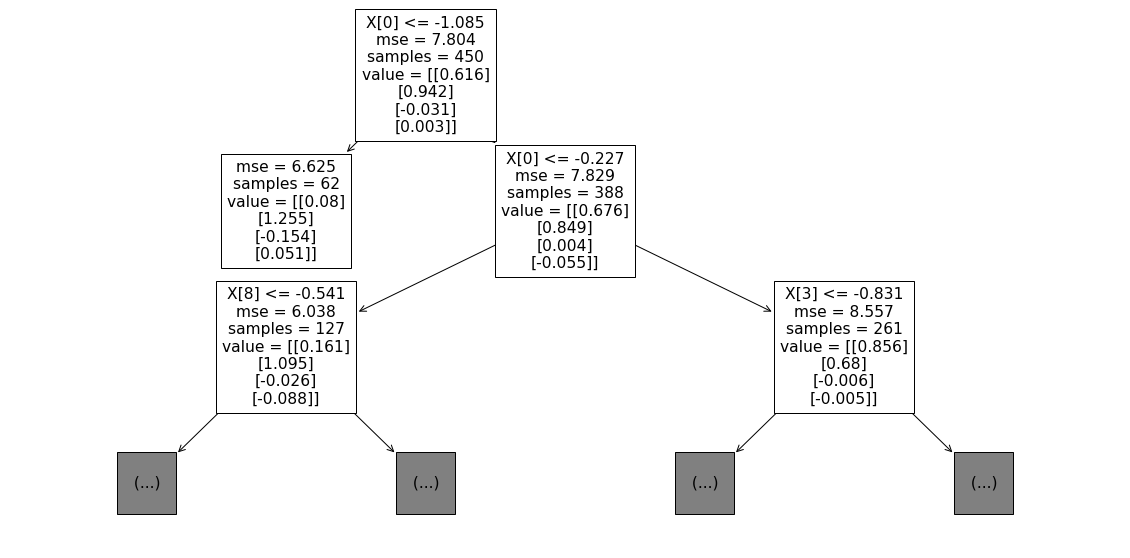

In [52]:
plt.figure(figsize=(20, 10))
plot_tree(est[0], impurity=True, max_depth=2)
plt.show()

In [53]:
import shap
explainer = shap.Explainer(est, shap.maskers.Independent(X, max_samples=100))
shap_values = explainer(X[:200])

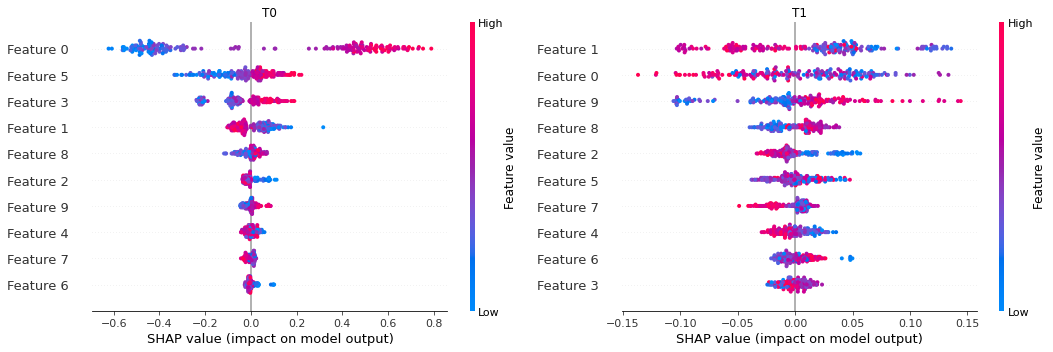

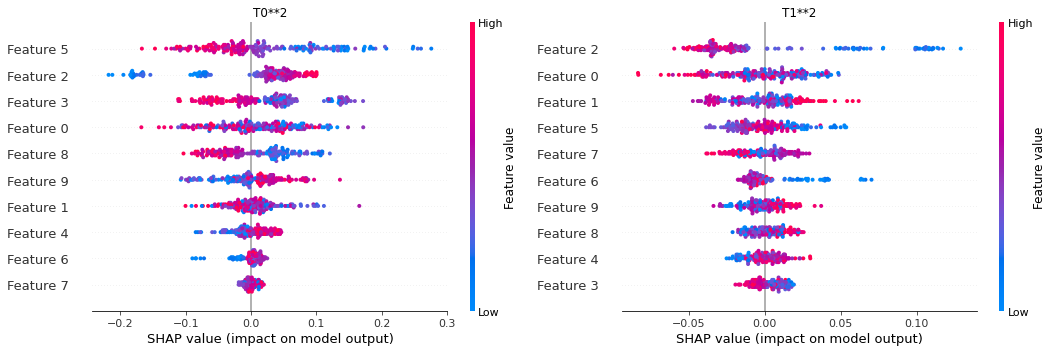

In [54]:
plt.figure(figsize=(15, 5))
for t in range(n_treatments):
    plt.subplot(1, n_treatments, t + 1)
    plt.title("T{}".format(t))
    shap.plots.beeswarm(shap_values[..., t], plot_size=None, show=False)
plt.tight_layout()
plt.show()
plt.figure(figsize=(15, 5))
for t in range(n_treatments):
    plt.subplot(1, n_treatments, t + 1)
    plt.title("T{}**2".format(t))
    shap.plots.beeswarm(shap_values[..., t + n_treatments], plot_size=None, show=False)
plt.tight_layout()
plt.show()